# Topological phase diagram of the Haldane model
In this example we will compute the topological phase diagram of the Haldane model with Anderson or Bernoulli disorder using the single-point Chern number.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberrypy as strw

In [2]:
# Set the parameters of the Haldane model
L = 24
t = -4
t2 = abs(t) / 4
delta = 1.25 * t
phi = -np.pi / 2

# Import a model from the examples
h_model = strw.example_models.haldane_tbmodels(delta, t, t2, phi)

# Create a supercell of size L x L
hmodel_sc = strw.Model(model=h_model, spinful=False).make_supercell(Lx=L, Ly=L)

In [3]:
# The seed parameter is used to generate the random disorder
s = 12345

# Add a random uniformly distributed on-site term (Anderson disorder) in the
#   interval [-W/2, W/2]. The disorder is added in-place, so the Hamiltonian
#   of the model is modified
# hmodel_sc.add_disorder_uniform(w=6.5 * abs(t), seed=s)

# Add a random Bernoulli distributed on-site term (binary disorder) with values -W/2
#   and W/2
disorder = hmodel_sc.add_disorder_bernoulli(w=1.1, seed=s)

print("On-site terms added to the model:")
print(disorder)

On-site terms added to the model:
[-0.55  0.55  0.55 ... -0.55  0.55  0.55]


In [4]:
# Set the disorder amplitude W and the number of seeds to average over
W_arr = np.linspace(0, 10 * abs(t), 21)
num_seeds = 3
sp_arr = np.zeros((len(W_arr), num_seeds))

In [5]:
# Loop over seeds and disorder amplitudes
for s_idx, s in enumerate(range(num_seeds)):
    for w_idx, W in enumerate(W_arr):
        # Redefine the model
        hmodel_sc = strw.Model(model=h_model, spinful=False).make_supercell(Lx=L, Ly=L)

        # Add Anderson disorder
        hmodel_sc.add_disorder_uniform(w=W, seed=s)

        # Collect the symmetric single-point Chern number
        sp_arr[w_idx, s_idx] += hmodel_sc.single_point_chern(
            formula="both", return_ham_gap=False
        )["symmetric"]

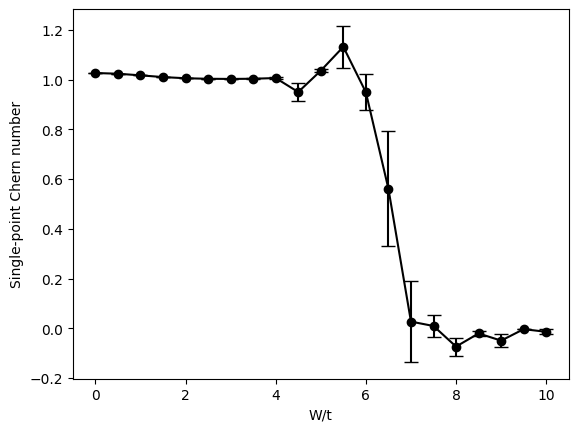

In [6]:
# Plot the results
fig, ax = plt.subplots()

ax.errorbar(W_arr / abs(t), sp_arr.mean(axis=1),
    yerr=sp_arr.std(axis=1) / np.sqrt(num_seeds),
    fmt="o-", capsize=5, color="black",
)

ax.set_xlabel("W/t")
ax.set_ylabel("Single-point Chern number");